# A look into the mass balance calibration in OGGM v1.6

The default mass-balance (MB) model of OGGM is a very standard [temperature index melt model](https://doi.org/10.1016/S0022-1694(03)00257-9). 

In versions before 1.6, OGGM had a complex calibration procedure which originated from the times, where we had only observations from a few hundred glaciers. We used them to calibrate the model and then a so-called infamous *tstar* (infamous in very niche circles of first- and second-gen OGGMers) which was interpolated to glaciers without observations (see the [original publication](https://www.the-cryosphere.net/6/1295/2012/tc-6-1295-2012.html)). This method was very powerful but, as new observational datasets emerged, we can now calibrate on a glacier-per-glacier basis. With the new era of geodetic observations, OGGM uses the average geodetic observations from Jan 2000--Jan 2020 of [Hugonnet al. 2021](https://www.nature.com/articles/s41586-021-03436-z), that are now available for almost every glacier world-wide.

Pre-processed directories from OGGM (from the Bremen server) have been calibrated for you, based on a specific climate dataset (W5E5) and our own dedicated calibration strategy. But, what if you want to use another climate dataset? Or another reference dataset?

In this notebook, we will:
- introduce the new flexible calibration method available to all users since OGGM v1.6: [mb_calibration_from_scalar_mb](https://docs.oggm.org/en/latest/generated/oggm.tasks.mb_calibration_from_scalar_mb.html)
- show how users can apply it (and extend it) for their own workflow
- explain how we used it to calibrate the OGGM pre-processed directories

## Set-up

In [1]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np

from oggm import cfg, utils, workflow, tasks, graphics
from oggm.core import massbalance
from oggm.core.massbalance import mb_calibration_from_scalar_mb, mb_calibration_from_geodetic_mb, mb_calibration_from_wgms_mb, mb_calibration_to_rmsd
from oggm.utils import rmsd

In [2]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-mb', reset=True)
cfg.PARAMS['border'] = 80

2026-06-05 14:30:44: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-06-05 14:30:44: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-06-05 14:30:44: oggm.cfg: Multiprocessing: using all available processors (N=16)


We start from two well known glaciers in the Austrian Alps, Kesselwandferner and Hintereisferner. But you can also choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv).

In [3]:
# we start from preprocessing level 3
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2025.6/elev_bands/W5E5/per_glacier'
gdirs = workflow.init_glacier_directories(['RGI60-11.00787',  'RGI60-11.00897'], from_prepro_level=3, prepro_base_url=base_url)

2026-06-05 14:30:44: oggm.workflow: init_glacier_directories from prepro level 3 on 2 glaciers.
2026-06-05 14:30:44: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 2 glaciers


The two glaciers are neighbors but have very different geometries:

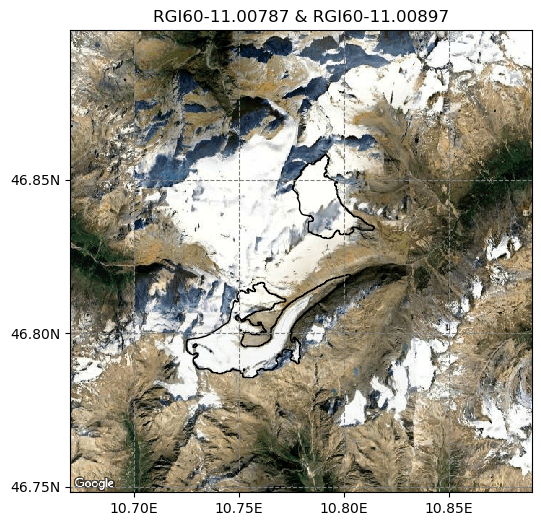

In [4]:
f, ax = plt.subplots(1,1,figsize=(6, 6))
graphics.plot_googlemap(gdirs[:2], ax=ax)
ax.set_title(gdirs[0].rgi_id + ' & ' + gdirs[1].rgi_id);

## Calibrated mass balance parameters in OGGM v1.6 pre-processed directories

We just downloaded the data. Let's have a look at the climate data we used and the calibrated parameters:

In [5]:
# Pick each glacier
gdir_kwf = gdirs[0]
gdir_hef = gdirs[1]

In [6]:
gdir_hef.get_climate_info()

{'baseline_climate_source': 'GSWP3_W5E5',
 'baseline_yr_0': np.int64(1901),
 'baseline_yr_1': np.int64(2019),
 'baseline_climate_ref_hgt': np.float32(2252.0),
 'baseline_climate_ref_pix_lon': np.float64(10.75),
 'baseline_climate_ref_pix_lat': np.float64(46.75)}

This is called the "baseline climate" in OGGM and is necessary to calibrate the model against observations. Ideally, the baseline climate should be real observations as perfect as possible, but in reality this is not the case. Often, gridded climate datasets have biases - we need to take this into account during our calibration. Let's have a look at the mass balance parameters for both glaciers:

In [7]:
gdir_hef.read_json('mb_calib')

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 5.0,
 'prcp_fac': 3.570255710475343,
 'temp_bias': 1.705035916562294,
 'reference_mb': -1100.3,
 'reference_mb_err': 171.8,
 'reference_period': '2000-01-01_2020-01-01',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

In [8]:
gdir_kwf.read_json('mb_calib')

{'rgi_id': 'RGI60-11.00787',
 'bias': 0,
 'melt_f': 5.0,
 'prcp_fac': 2.922352594344337,
 'temp_bias': 1.705035916562294,
 'reference_mb': -514.8000000000001,
 'reference_mb_err': 136.3,
 'reference_period': '2000-01-01_2020-01-01',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

We will explain later what all these mean. Let's focus on these for now: `melt_f`, `prcp_fac`, and `temp_bias` which have been calibrated with `reference_mb` over the reference period `reference_period`.

Per default the [Hugonnet et al. (2021)](https://www.nature.com/articles/s41586-021-03436-z) average geodetic observation is used over the entire time period Jan 2000 to Jan 2020 to calibrate the MB model parameter(s) for every single glacier.

For our two neighboring example glaciers, that share the same climate gridpoint, the same pre-calibrated `temp_bias` and the same `melt_f` is used. The `prcp_fac` is slightly different, hence in that example, changing the `prcp_fac` within the narrow range of $[0.8,1.2]$ was sufficient to match the MB model to the observations.

Note that the two glaciers are in the same climate (from the forcing data) but are very different in size, orientation and geometry. So, at least one of the MB model parameters is different (here the `prcp_fac`) and also the observed MB values vary:

In [9]:
for gdir in gdirs:
    mbmod = massbalance.MonthlyTIModel(gdir)
    mean_mb = mbmod.get_specific_mb(fls=gdir.read_pickle('inversion_flowlines'),
                                               year=np.arange(2000,2020,1)).mean()
    print(gdir.rgi_id, f': average MB 2000-2020 = {mean_mb:.1f} kg m-2, ',
          f"prcp_fac: {gdir.read_json('mb_calib')['prcp_fac']:.2f}")

RGI60-11.00787 : average MB 2000-2020 = -514.8 kg m-2,  prcp_fac: 2.92
RGI60-11.00897 : average MB 2000-2020 = -1100.3 kg m-2,  prcp_fac: 3.57


*Kesselwandferner has a less negative MB than its neighbor, probably because it is smaller in size and spans less altitude. To simplify things, we will now focus just on one glacier (Hintereisferner), but you can repeat it of course with other glaciers.*

<div class="alert alert-info">
    <b>
        How are these parameters calibrated by OGGM? How can I calibrate them for my use case? <br>
        These are the questions we want to address in the rest of the notebook. We  will change the three MB model parameters (melt_f, temp_bias and prcp_fac) and see their influence on the calibration, to allow users to make an informed decision on how to calibrate them for their purpose. Then we will go back to the calibration method used by OGGM for the preprocessed directories.
    </b>
</div>

Note also that there are some global MB parameters (`mb_global_params`), which we assume to be the same globally for every glacier:

In [10]:
gdir_hef.read_json('mb_calib')['mb_global_params']

{'temp_default_gradient': -0.0065,
 'temp_all_solid': 0.0,
 'temp_all_liq': 2.0,
 'temp_melt': -1.0}

These global MB parameter values were found to represent best the in-situ observations during a cross-validation for glaciers with additional observations. Of course, they could also be changed for different glaciers, but this would need even more data to justify the differences! The influence of using a different temperature lapse rate gradient to the default -0.0065 K/km are analysed in [Schuster et al., 2023](https://doi.org/10.1017/aog.2023.57).

First, let's check if the OGGM calibration worked at all

- we will get first the average modelled MB:

In [11]:
h, w = gdir_hef.get_inversion_flowline_hw()
mb_geod = massbalance.MonthlyTIModel(gdir_hef)
# Note, if you change cfg.PARAMS['geodetic_mb_period'], you need to change the years here as well!
mbdf= pd.DataFrame(index = np.arange(2000,2020,1))
mbdf['mod_mb'] = mb_geod.get_specific_mb(h, w, year=mbdf.index)
mbdf.mean()

mod_mb   -1100.3
dtype: float64

- then get the observed geodetic MB that we calibrated our mass-balance to:

In [12]:
print('reference MB: ' + str(gdir_hef.read_json('mb_calib')['reference_mb'])+ ' kg m-2')
print('reference MB uncertainties: '+ str(gdir_hef.read_json('mb_calib')['reference_mb_err'])+ ' kg m-2')
print('reference MB time period: ' + gdir_hef.read_json('mb_calib')['reference_period'])

reference MB: -1100.3 kg m-2
reference MB uncertainties: 171.8 kg m-2
reference MB time period: 2000-01-01_2020-01-01


   - We calibrated on the entire 20-yr time period, because then the observational uncertainties are smallest.

In [13]:
# this tests if the two parameters are very similar:
np.testing.assert_allclose(gdir_hef.read_json('mb_calib')['reference_mb'], mbdf['mod_mb'].mean())

Perfect! Our MB model reproduces the average observed MB, so the calibration worked!

## The new flexible calibration scheme in OGGM

We have now used the option that is applied in the preprocessed directories. However, there are many other calibration options. We will show you some options, but you could also invent your own!

**Calibrate `melt_f`, fixed `prcp_fac` and `temp_bìas`**

For example, let's calibrate the `melt_f` to match the same observations as before (i.e., average geodetic observation) and fix the other parameters. We will use the more general function [mb_calibration_from_scalar_mb](https://docs.oggm.org/en/latest/generated/oggm.tasks.mb_calibration_from_scalar_mb.html) which is more flexible. However, it requires you to give manually the observed MB on which you want to calibrate:

In [14]:
# if you use the default calibration data from Hugonnet et al., 2021,
# we can get the geodetic data from any glacier from here:
ref_mb_df = utils.get_geodetic_mb_dataframe().loc[gdir_hef.rgi_id]
ref_mb_df = ref_mb_df.loc[ref_mb_df['period'] == cfg.PARAMS['geodetic_mb_period']].iloc[0]
# dmdtda: in meters water-equivalent per year -> we convert to kg m-2 yr-1
ref_mb = ref_mb_df['dmdtda'] * 1000
ref_mb

np.float64(-1100.3)

In [15]:
# Let's calibrate the melt_f (this is the default option in mb_calibration_from_scalar_mb)
# overwrite_gdir has to be set to True,
# because we want to overwrite the old calibration
mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb,
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              overwrite_gdir=True);

mb_melt_f = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_melt_f'] = mb_melt_f.get_specific_mb(h, w, year=mbdf.index)

Let's read the new calibrated MB model parameter for the glacier:

In [16]:
gdir_hef.read_json('mb_calib')

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 8.778498382814007,
 'prcp_fac': 3.3571363074447045,
 'temp_bias': 0,
 'reference_mb': -1100.3,
 'reference_mb_err': None,
 'reference_period': '2000-01-01_2020-01-01',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

Only `melt_f` is used to calibrate the MB model. `prcp_fac` was chosen depending on the average winter precipitation (explained below) and `temp_bias` is 0.

**Calibrate `temp_bias`, fixed `prcp_fac` and `melt_f`**

We will now instead fix the `melt_f` and the `prcp_fac`, and use the `temp_bias` as free variable for calibration. For that we overwrite the default value of `calibrate_param1`:

In [17]:
# Let's calibrate on the temp_bias instead
# overwrite_gdir has to be set to True,
# because we want to overwrite the old calibration
mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb,
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='temp_bias',
                              overwrite_gdir=True)

mb_temp_b = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_temp_b'] = mb_temp_b.get_specific_mb(h, w, year=mbdf.index)

In [18]:
mb_params = gdir_hef.read_json('mb_calib')
mb_params['temp_bias'], mb_params['prcp_fac'], mb_params['melt_f']

(1.5881521791866742, 3.3571363074447045, 5.0)

Here we used the median `melt_f` (i.e., 5 kg m-2 day-1 K-1) and the same `prcp_fac` as in the previous option, but changed `temp_bias` until the `ref_mb` is matched. As the `melt_f` is lower than in the previous calibration option, we need to have a positive `temp_bias` to get to the same average MB (i.e., `ref_mb`).

**Calibrate `prcp_fac`, fixed `temp_bias` and `melt_f`**

Similarly, we can also just calibrate on the precipitation factor (`prcp_fac`).

In [19]:
# Let's calibrate on the prcp_fac instead
# overwrite_gdir has to be set to True,
# because we want to overwrite the old calibration
mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb,
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='prcp_fac',
                              overwrite_gdir=True)

mb_prcp_fac = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_prcp_fac'] = mb_prcp_fac.get_specific_mb(h, w, year=mbdf.index)

mb_params = gdir_hef.read_json('mb_calib')
mb_params['temp_bias'], mb_params['prcp_fac'], mb_params['melt_f']

(0, 1.1040206148538605, 5.0)

We chose two glaciers that actually have also in-situ observations available. 
We will get the in-situ observations like that:

In [20]:
mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']
# if we want to compare the average to the average geodetic MB, we need to have all years available
assert len(mbdf['in_situ_mb']) == 20

Let's plot how well we match the interannual observations for the different calibration options:

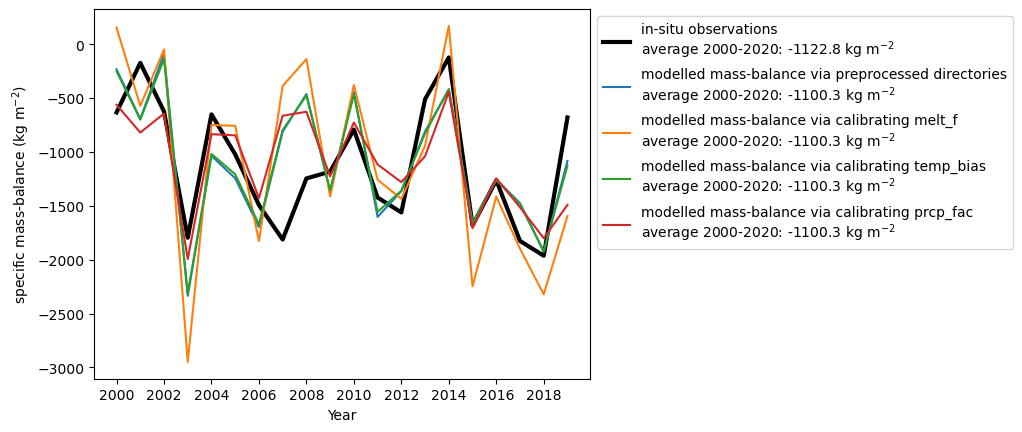

In [21]:
plt.plot(mbdf['in_situ_mb'], label='in-situ observations\n'+f'average 2000-2020: {mbdf.in_situ_mb.mean():.1f} '+ r'kg m$^{-2}$', color='k', lw=3)
plt.plot(mbdf['mod_mb'],
         label='modelled mass-balance via preprocessed directories\n'+f'average 2000-2020: {mbdf.mod_mb.mean():.1f} ' + r'kg m$^{-2}$')
plt.plot(mbdf['mod_mb_melt_f'],
         label='modelled mass-balance via calibrating melt_f\n'+f'average 2000-2020: {mbdf.mod_mb.mean():.1f} ' + r'kg m$^{-2}$')
plt.plot(mbdf['mod_mb_temp_b'],
         label='modelled mass-balance via calibrating temp_bias\n'+f'average 2000-2020: {mbdf.mod_mb_temp_b.mean():.1f} ' + r'kg m$^{-2}$')
plt.plot(mbdf['mod_mb_prcp_fac'],
         label='modelled mass-balance via calibrating prcp_fac\n'+f'average 2000-2020: {mbdf.mod_mb_prcp_fac.mean():.1f} ' + r'kg m$^{-2}$')
plt.xticks(np.arange(2000,2020,2))
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel(r'specific mass-balance (kg m$^{-2}$)')
plt.xlabel('Year');

For this glacier, over the same time period (here 2000-2020), the average MB is quite similar between the geodetic and in-situ observation and could even be explained by the fact that the in-situ observations are in hydrological years (starting in October of the previous year) and the geodetic observations are in calendar years. If you repeat the analysis for other glaciers with in-situ observations over that time period, you might see larger discrepancies. 

You can also see, that there are differences in the annual MB between the calibration options and the in-situ observations. We will analyse these differences more systematically later!

## Calibrate on direct glaciological in-situ MB observations

Ok, but actually you might trust the in-situ observations much more than the geodetic observation. So if you are only interested in glaciers with these in-situ observations, you can also use the in-situ observations for calibration. This might allow you also to calibrate over a longer time period and to use additional information (such as the interannual MB variability, seasonal MB, ...). However, bear in mind that there are often gaps in the in-situ MB time series and make sure that you calibrate to the same modelled time period!

Attention: For the Hintereisferner glacier with an almost 70-year long time series, the assumption that we make, i.e., that the area does not change over the time period, gets more problematic. So think twice before repeating this at home!

In [22]:
mb_calibration_from_wgms_mb(gdir_hef, overwrite_gdir=True)

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 10.834643474756085,
 'prcp_fac': np.float64(3.3571363074447045),
 'temp_bias': 0,
 'reference_mb': np.float64(-648.223880597015),
 'reference_mb_err': None,
 'reference_period': 'custom',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

`mb_calibration_from_wgms_mb` is a short-cut function that uses internally `mb_calibration_from_scalar_mb`,
but applies directly the average annual in-situ MB observations from the WGMS. Per default, the `melt_f` is calibrated, and `prcp_fac` and `temp_bias` are fixed. You can get the observations like that:

In [23]:
mbdf_in_situ = gdir_hef.get_ref_mb_data()
mbdf_in_situ['ref_mb'] = mbdf_in_situ['ANNUAL_BALANCE']
# check that every year between the beginning and the end has MB observations
assert len(mbdf_in_situ.index) == (mbdf_in_situ.index[-1] - mbdf_in_situ.index[0] + 1)
ref_mb = mbdf_in_situ.ref_mb.mean()

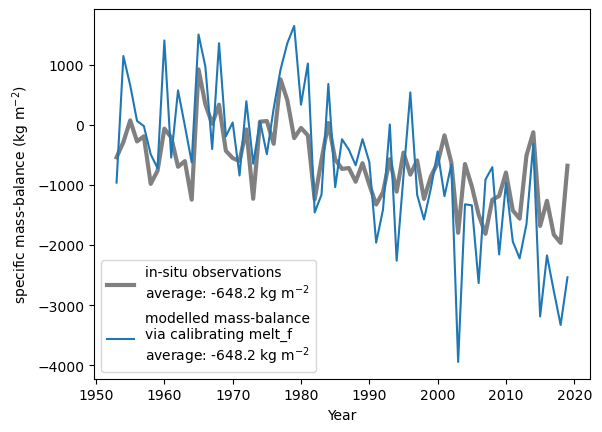

In [24]:
mb_in_situ_obs = massbalance.MonthlyTIModel(gdir_hef)
mbdf_in_situ['mod_mb'] = mb_in_situ_obs.get_specific_mb(h, w, year=mbdf_in_situ.index)
plt.plot(mbdf_in_situ['ref_mb'],
         label='in-situ observations\n'+f'average: {ref_mb:.1f} '+ r'kg m$^{-2}$', color='grey', lw=3)
plt.plot(mbdf_in_situ['mod_mb'],
         label=('modelled mass-balance\nvia calibrating melt_f\n'
                +f'average: {mbdf_in_situ.mod_mb.mean():.1f} ' + r'kg m$^{-2}$'))

plt.legend()
plt.ylabel(r'specific mass-balance (kg m$^{-2}$)')
plt.xlabel('Year');

In [25]:
mbdf_in_situ[['ref_mb','mod_mb']].mean()

ref_mb   -648.223881
mod_mb   -648.223881
dtype: float64

The average MB over the entire time period is matched as we calibrate to it. However, the interannual mass-balance variability is different. How well the modelled annual mass-balance time series matches the observations can be for example assessed by looking at the correlation between modelled and observed annual MB:

In [26]:
mbdf_in_situ[['ref_mb','mod_mb']].corr().values[0][1]

np.float64(0.807518163502817)

or by looking into the standard deviation of interannual MB variability, where we see a much larger variability for the modelled MB:

In [27]:
mbdf_in_situ[['ref_mb','mod_mb']].std()

ref_mb     624.538759
mod_mb    1238.782934
dtype: float64

### Calibrating on direct glaciological in-situ MB observations by minimising the RMSD

In the previous section, we calibrated the model using in-situ observations via `mb_calibration_from_wgms_mb`, which internally relies on `mb_calibration_from_scalar_mb`. This approach minimises the *mean difference* between model and observations. While effective, it reduces the dataset to its average value and therefore ignores valuable information about year-to-year variability.

However, WGMS mass balance observations provide *annual* values over the observation period. This richer dataset allows us to use calibration methods that account for interannual variability.

OGGM now provides such a method: `mb_calibration_to_rmsd`. Instead of focusing only on the mean, it minimises the Root Mean Square Deviation (RMSD) between observed and modelled annual mass balance values.

Another key difference is that this method performs a **multi-parameter optimisation**, whereas previous approaches typically optimise one parameter at a time.

In the following, we compare this RMSD-based calibration to the previous approach, focusing on differences in mean, variability (standard deviation), and overall fit.

In [28]:
# The mass balance time series generated by calibrating melt_f
# to minimise the mean mass balance using mb_calibration_from_wgms_mb
print(f"RMSD: {rmsd(mbdf_in_situ['ref_mb'], mbdf_in_situ['mod_mb']):.2f} kg m-2")

sd_diff = abs(mbdf_in_situ['ref_mb'].std() - mbdf_in_situ['mod_mb'].std())
print(f"Std dev difference: {sd_diff:.2f} kg m-2")

mean_diff = abs(mbdf_in_situ['ref_mb'].mean() - mbdf_in_situ['mod_mb'].mean())
print(f"Mean difference: {mean_diff:.2f} kg m-2")

RMSD: 815.51 kg m-2
Std dev difference: 614.24 kg m-2
Mean difference: 0.00 kg m-2


The difference in mean mass balance is negligible. However, the differences in standard deviation and RMSD are much larger, indicating that important aspects of the variability are not well captured.

Let us now consider an alternative approach, using the RMSD as the cost function.

We begin by calibrating only the melt factor, while keeping the temperature bias and precipitation factor fixed at their default values. If no calibration parameters are specified, the function uses this configuration by default.

In [29]:
mb_calibration_to_rmsd(gdir_hef, ref_df=mbdf_in_situ['ref_mb'], overwrite_gdir=True)

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': np.float64(9.96459794240686),
 'prcp_fac': np.float64(3.3571363074447045),
 'temp_bias': 0,
 'reference_mb': np.float64(-648.223880597015),
 'reference_mb_err': None,
 'reference_period': '[1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963 1964 1965 1966\n 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980\n 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994\n 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008\n 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019]',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5',
 'rmsd': np.float64(780.2212095336902)}

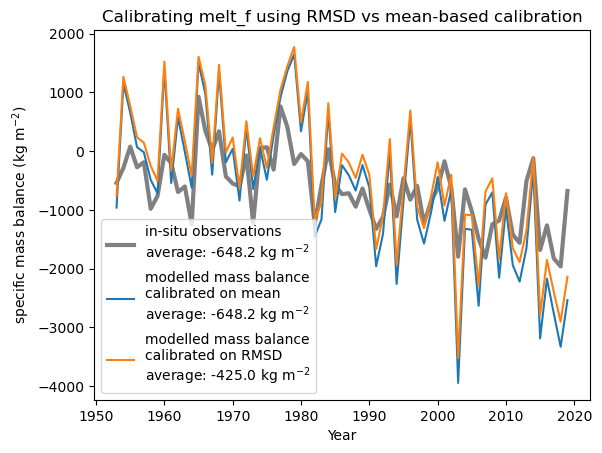

In [30]:
mbmod_rmsd = massbalance.MonthlyTIModel(gdir_hef)
mbdf_in_situ['mod_mb_rmsd'] = mbmod_rmsd.get_specific_mb(
    h, w, year=mbdf_in_situ.index
)

ref = mbdf_in_situ['ref_mb']
mod_mean = mbdf_in_situ['mod_mb']
mod_rmsd = mbdf_in_situ['mod_mb_rmsd']

plt.plot(
    ref,
    color='grey',
    lw=3,
    label=(
        "in-situ observations\n"
        f"average: {ref.mean():.1f} " + r"kg m$^{-2}$"
    ),
)

plt.plot(
    mod_mean,
    label=(
        "modelled mass balance\n"
        "calibrated on mean\n"
        f"average: {mod_mean.mean():.1f} " + r"kg m$^{-2}$"
    ),
)

plt.plot(
    mod_rmsd,
    label=(
        "modelled mass balance\n"
        "calibrated on RMSD\n"
        f"average: {mod_rmsd.mean():.1f} " + r"kg m$^{-2}$"
    ),
)

plt.legend()
plt.ylabel(r"specific mass balance (kg m$^{-2}$)")
plt.xlabel("Year")
plt.title("Calibrating melt_f using RMSD vs mean-based calibration")
plt.show()

In [31]:
print(f"RMSD: {rmsd(mbdf_in_situ['ref_mb'], mbdf_in_situ['mod_mb_rmsd']):.2f} kg m-2")

sd_diff = abs(mbdf_in_situ['ref_mb'].std() - mbdf_in_situ['mod_mb_rmsd'].std())
print(f"Std dev difference: {sd_diff:.2f} kg m-2")

mean_diff = abs(mbdf_in_situ['ref_mb'].mean() - mbdf_in_situ['mod_mb_rmsd'].mean())
print(f"Mean difference: {mean_diff:.2f} kg m-2")

RMSD: 780.22 kg m-2
Std dev difference: 536.20 kg m-2
Mean difference: 223.24 kg m-2


We can see a slight reduction in the RMSD and the differences in the standard deviation, however, now our differences in the means is far larger. Overall, all of these errors are still quite large. Let's see if we can reduce these errors further...

Now let's try by calibrating all of the mass-balance parameters.

In [32]:
mb_calibration_to_rmsd(gdir_hef, ref_df=mbdf_in_situ['ref_mb'], overwrite_gdir=True,
                       calibrate_params=('melt_f', 'prcp_fac', 'temp_bias'))

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': np.float64(3.8275301950281397),
 'prcp_fac': np.float64(1.5734495032699196),
 'temp_bias': np.float64(1.2712660014944723),
 'reference_mb': np.float64(-648.223880597015),
 'reference_mb_err': None,
 'reference_period': '[1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963 1964 1965 1966\n 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980\n 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994\n 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008\n 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019]',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5',
 'rmsd': np.float64(353.7527998459982)}

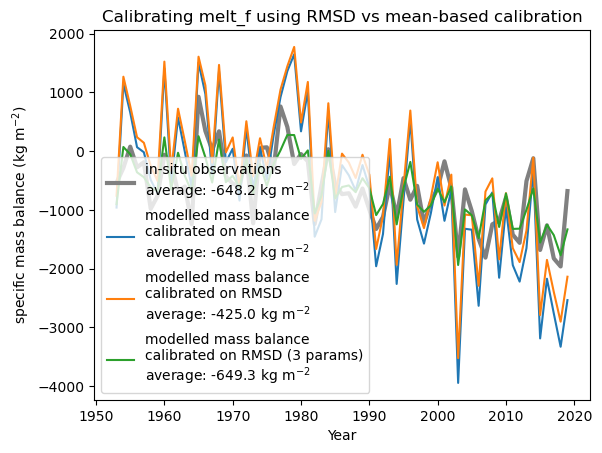

In [33]:
mbmod_rmsd3 = massbalance.MonthlyTIModel(gdir_hef)
mbdf_in_situ['mod_mb_rmsd3'] = mbmod_rmsd3.get_specific_mb(h, w, year=mbdf_in_situ.index)

ref = mbdf_in_situ['ref_mb']
mod_mean = mbdf_in_situ['mod_mb']
mod_rmsd = mbdf_in_situ['mod_mb_rmsd']
mod_rmsd3 = mbdf_in_situ['mod_mb_rmsd3']

plt.plot(
    ref,
    color='grey',
    lw=3,
    label=(
        "in-situ observations\n"
        f"average: {ref.mean():.1f} " + r"kg m$^{-2}$"
    ),
)

plt.plot(
    mod_mean,
    label=(
        "modelled mass balance\n"
        "calibrated on mean\n"
        f"average: {mod_mean.mean():.1f} " + r"kg m$^{-2}$"
    ),
)

plt.plot(
    mod_rmsd,
    label=(
        "modelled mass balance\n"
        "calibrated on RMSD\n"
        f"average: {mod_rmsd.mean():.1f} " + r"kg m$^{-2}$"
    ),
)

plt.plot(
    mod_rmsd3,
    label=(
        "modelled mass balance\n"
        "calibrated on RMSD (3 params)\n"
        f"average: {mod_rmsd3.mean():.1f} " + r"kg m$^{-2}$"
    ),
)

plt.legend()
plt.ylabel(r"specific mass balance (kg m$^{-2}$)")
plt.xlabel("Year")
plt.title("Calibrating melt_f using RMSD vs mean-based calibration")
plt.show()

In [34]:
print(f"RMSD: {rmsd(mbdf_in_situ['ref_mb'], mbdf_in_situ['mod_mb_rmsd3']):.2f} kg m-2")

sd_diff = abs(mbdf_in_situ['ref_mb'].std() - mbdf_in_situ['mod_mb_rmsd3'].std())
print(f"Std dev difference: {sd_diff:.2f} kg m-2")

mean_diff = abs(mbdf_in_situ['ref_mb'].mean() - mbdf_in_situ['mod_mb_rmsd3'].mean())
print(f"Mean difference: {mean_diff:.2f} kg m-2")

RMSD: 353.75 kg m-2
Std dev difference: 113.12 kg m-2
Mean difference: 1.11 kg m-2


When calibrating all three mass-balance parameters simultaneously, we can identify more optimal parameter combinations that reduce the RMSD, while also improving the agreement in mean and standard deviation.

This approach provides an alternative calibration strategy that captures multiple characteristics of the dataset, rather than focusing solely on the mean mass balance.

### Dealing with errors and including your own mass-balance observations

Let's look at another glacier, now in Central Asia, for example the Golubin glacier:

2026-06-05 14:30:52: oggm.workflow: init_glacier_directories from prepro level 3 on 1 glaciers.
2026-06-05 14:30:52: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers
100% of 331.1 MiB |######################| Elapsed Time: 0:04:24 Time:  0:04:2421


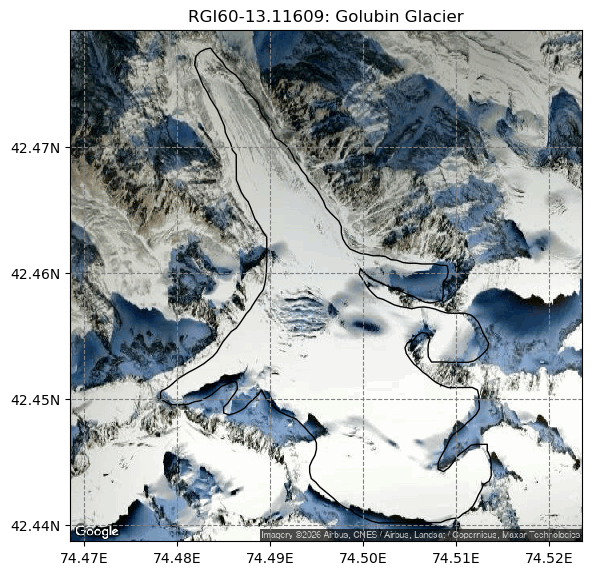

In [35]:
gdir_gol = workflow.init_glacier_directories(['RGI60-13.11609'], from_prepro_level=3, prepro_base_url=base_url)[0]

tasks.process_climate_data(gdir_gol)

f, ax = plt.subplots(1,1,figsize=(6, 6))
graphics.plot_googlemap([gdir_gol], ax=ax)
plt.tight_layout()

Let's calibrate that glacier by only changing the `melt_f`, default in `mb_calibration_from_scalar_mb`:

In [36]:
# first need to get the MB observations again
ref_mb_df = utils.get_geodetic_mb_dataframe().loc[gdir_gol.rgi_id]
ref_mb_df = ref_mb_df.loc[ref_mb_df['period'] == cfg.PARAMS['geodetic_mb_period']].iloc[0]
# dmdtda: in meters water-equivalent per year -> we convert to kg m-2 yr-1
ref_mb = ref_mb_df['dmdtda'] * 1000
ref_mb

np.float64(-255.9)

In [37]:
# Note that this will create an error!
import pytest
with pytest.raises(RuntimeError):
    mb_calibration_from_scalar_mb(gdir_gol, ref_mb=ref_mb, ref_period = cfg.PARAMS['geodetic_mb_period'])

2026-06-05 14:35:18: oggm.core.massbalance: RuntimeError occurred during task mb_calibration_from_scalar_mb on RGI60-13.11609: RGI60-13.11609: ref mb not matched. Try to set calibrate_param2.


We got a `RuntimeError` that says that the `ref_mb` is not matched and that we should set `calibrate_param2`. What happened? 

Well, no `melt_f` parameter could be found in the given ranges to reproduce the given calibration data (`ref_mb`). 

In [38]:
# What are the current minimum and maximum ranges of the melt factor (unit: kg m-2 day-1 K-1)
cfg.PARAMS['melt_f_min'], cfg.PARAMS['melt_f_max']

(1.5, 17.0)

If we believe that our observations are true, maybe the climate or the processes represented by the MB model are erroneous. 

What can we do to still match the `ref_mb`? We can either change the `melt_f` ranges by setting other values to the parameters above, or we can allow that another MB model parameter is changed (i.e., `calibrate_param2`). This is basically very similar to the three-step-calibration
first introduced in [Huss & Hock 2015](https://doi.org/10.3389/feart.2015.00054), but here you can choose your parameter ranges and parameter order yourself. 

To reduce these MB model calibration errors, you can first change the `melt_f`, fix it at the lower or upper limit, and then change the `temp_bias`.

In [39]:
# Allowing another parameter to change is done by defining calibrate_param2
mb_calibration_from_scalar_mb(gdir_gol, ref_mb=ref_mb,
                              write_to_gdir=False,
                              ref_period =cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='melt_f',
                              calibrate_param2='temp_bias')

{'rgi_id': 'RGI60-13.11609',
 'bias': 0,
 'melt_f': 1.5,
 'prcp_fac': np.float64(3.768656910471054),
 'temp_bias': -0.5504307881497134,
 'reference_mb': np.float64(-255.9),
 'reference_mb_err': None,
 'reference_period': '2000-01-01_2020-01-01',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

The `melt_f` is at the minimum value and temperature was corrected to more negative values to allow for the relatively weak negative MB.  

**Use your own or fake MB observations for calibration**

In the same way, you can also use your own MB observations or fake data to calibrate the MB model. We use here as an example, an unrealistically high positive MB for the Hintereisferner over a 10-year period. To allow the calibration to happen, we need again to set `calibrate_param2`! Here we will use the `prcp_fac` as second parameter for a change:

In [40]:
ref_period = '2000-01-01_2010-01-01'
ref_mb = 2000 # Let's use an unrealistically positive mass-balance
mb_calibration_from_scalar_mb(gdir_hef, ref_mb=ref_mb,
                              ref_period=ref_period,
                              overwrite_gdir=True,
                              calibrate_param2='prcp_fac');

In [41]:
mb_new = massbalance.MonthlyTIModel(gdir_hef)
# ok, we actually matched the new ref_mb over the 10-yr period
np.testing.assert_allclose(ref_mb, mb_new.get_specific_mb(h, w, year=np.arange(2000,2010,1)).mean())
# Let's look at the calibrated parameters
gdir_hef.read_json('mb_calib')

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 1.5,
 'prcp_fac': 4.270384963139335,
 'temp_bias': 0,
 'reference_mb': 2000,
 'reference_mb_err': None,
 'reference_period': '2000-01-01_2010-01-01',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5',
 'rmsd': 353.7527998459982}

Ok, in that case, the climate was too warm to allow for such a positive MB. Even the smallest `melt_f` did not allow for such a positive MB. Therefore, the `prcp_fac` was increased to allow that more (solid) precipitation can occur. 

However, also the `prcp_fac` has a limited range: 

In [42]:
cfg.PARAMS['prcp_fac_min'], cfg.PARAMS['prcp_fac_max']

(0.1, 10.0)

So, if we increase the `ref_mb` even further, we might even need a third free parameter (i.e., we need to set `calibrate_param3`). 
Let's try it out, by using now the same order as in [Huss & Hock (2015)](https://doi.org/10.3389/feart.2015.00054) (but different allowed parameter changes that also depend on the chosen climate...):

That means, we match the `ref_mb` by 
- first trying to adapt `prcp_fac`,
- then `melt_f`,
- and finally `temp_bias`.

In [43]:
ref_mb = 6000 # if you replace it with 8000, no combination of parameters can be found for that glacier
mb_calibration_from_scalar_mb(gdir_hef,ref_mb=ref_mb,
                              ref_period=ref_period,
                              calibrate_param1='prcp_fac',
                              calibrate_param2='melt_f',
                              calibrate_param3='temp_bias',
                              overwrite_gdir=True)

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 1.5,
 'prcp_fac': 10.0,
 'temp_bias': -0.8884594171970883,
 'reference_mb': 6000,
 'reference_mb_err': None,
 'reference_period': '2000-01-01_2010-01-01',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5',
 'rmsd': 353.7527998459982}

In that case, the minimum `melt_f` and the maximum `prcp_fac` are applied. The `temp_bias` is set to a negative value as this results in more solid precipitation. If you increased the `ref_mb` even further, the method will not find any combination as the `temp_bias` also has a limited 
range. If you really want to match the observation, then you would need to change the parameter ranges.

In [44]:
cfg.PARAMS['temp_bias_min'], cfg.PARAMS['temp_bias_max']

(-15.0, 15.0)

Check out the docstring for more information about the options by uncommenting the line below!

In [45]:
# mb_calibration_from_scalar_mb?

## Overparameterisation or the magic choice of the best calibration option:

We found already some combinations that equally well match the average MB over a given time period. As we only use one observation per glacier (i.e., per default the average geodetic MB from 2000-2020), but have up to three free MB model parameters, the MB model is overparameterised. That means, there are in theory an infinite amount of calibration options possible that equally well match the one observation. Let's look a bit more systematically into that:

We will use a range of different `prcp_fac` and then calibrate the `melt_f` accordingly to always match to the default average MB (`ref_mb`) over the reference period (`ref_period`).

In [46]:
# let's go back to the Hintereisferner glacier and get again the MB observations:
ref_mb_df = utils.get_geodetic_mb_dataframe().loc[gdir_hef.rgi_id]
ref_mb_df = ref_mb_df.loc[ref_mb_df['period'] == cfg.PARAMS['geodetic_mb_period']].iloc[0]
ref_mb = ref_mb_df['dmdtda'] * 1000

In [47]:
# calibrate the melt_f and annual MB
# Create a dataframe with precip factor going from 0.1 to 5.0 in 0.3 steps
pd_prcp_fac_sens = pd.DataFrame(index=np.arange(0.1,5.0,0.3))
# Calibrate the melt factor for each of these
spec_mb_prcp_fac_sens_dict = {}
for prcp_fac in pd_prcp_fac_sens.index:
    calib_param = mb_calibration_from_scalar_mb(gdir_hef,
                                                ref_mb=ref_mb,
                                                ref_period=cfg.PARAMS['geodetic_mb_period'],
                                                prcp_fac=prcp_fac,
                                                overwrite_gdir=True)
    # Fill the dataframe with the calibrated parameters
    pd_prcp_fac_sens.loc[prcp_fac, 'melt_f'] = calib_param['melt_f']

    # Check the modelled massbalance
    mb_prcp_fac_sens = massbalance.MonthlyTIModel(gdir_hef)
    # ok, we actually matched the new ref_mb
    annual_mb = mb_prcp_fac_sens.get_specific_mb(h, w, year=np.arange(2000,2020,1))
    spec_mb_prcp_fac_sens_dict[prcp_fac] = annual_mb
    # let's also check how well the interannual MB variability is matched
    # by comparing the standard deviation of the annual MB to the observed one
    std_quot_annual_mb = annual_mb.std()/mbdf_in_situ.loc[2000:2019, 'ANNUAL_BALANCE'].std()
    pd_prcp_fac_sens.loc[prcp_fac, 'std_quot_annual_mb'] = std_quot_annual_mb

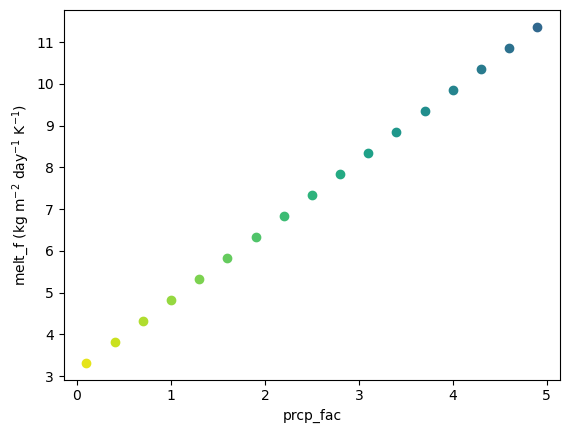

In [48]:
# let's get some nice colors visualising more precipitation
colors_prcp_fac = plt.get_cmap('viridis_r').colors[10::10]
plt.figure()
for j,prcp_fac in enumerate(pd_prcp_fac_sens.index):
    plt.plot(prcp_fac, pd_prcp_fac_sens.loc[prcp_fac, 'melt_f'],
             'o', color=colors_prcp_fac[j])
plt.ylabel(r'melt_f (kg m$^{-2}$ day$^{-1}$ K$^{-1}$)')
plt.xlabel('prcp_fac');

All these combinations match the average `ref_mb` equally. The larger the chosen `prcp_fac`, the larger needs to be the calibrated `melt_f` when matching to the same average MB.

What is the influence on the chosen parameter combination on other estimates than the average MB?

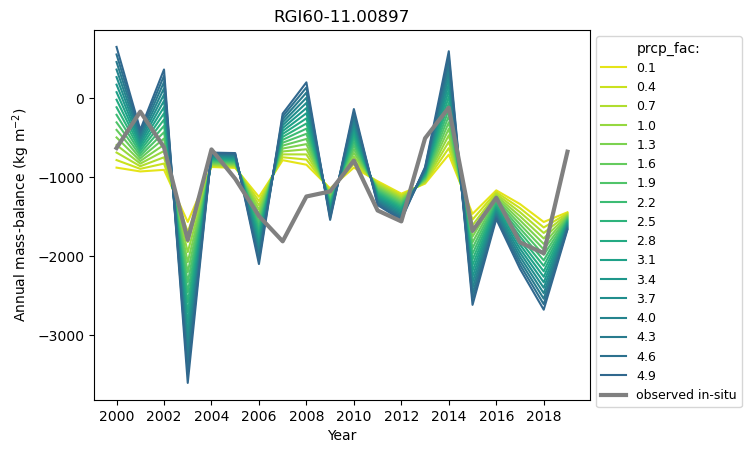

In [49]:
plt.figure()
for j,prcp_fac in enumerate(pd_prcp_fac_sens.index):
    plt.plot(np.arange(2000,2020,1),
             spec_mb_prcp_fac_sens_dict[prcp_fac], '-',
             color=colors_prcp_fac[j], label=f'{prcp_fac:.1f}')
plt.plot(mbdf_in_situ.loc[2000:2019].index,
         mbdf_in_situ.loc[2000:2019]['ANNUAL_BALANCE'],
         color='grey', lw=3,
        label='observed in-situ')
plt.ylabel(r'Annual mass-balance (kg m$^{-2}$)')
plt.xlabel('Year')
plt.legend(title='prcp_fac:', bbox_to_anchor=(1,1), fontsize=9)
plt.xticks(np.arange(2000,2020,2));
plt.title(gdir_hef.rgi_id);

The larger the `prcp_fac` and the `melt_f`, the larger is the interannual MB variability. For glaciers with in-situ observations, we can find a combination of `prcp_fac` and `melt_f` that has a similar interannual MB variability than the observations. For example, you can choose a MB model parameter combination where the standard deviation quotient of the annual modelled and observed MB is near to 1:

In [50]:
condi = (pd_prcp_fac_sens['std_quot_annual_mb'] < 1.1) & (pd_prcp_fac_sens['std_quot_annual_mb'] > 0.9)
pd_prcp_fac_sens[condi]

,melt_f,std_quot_annual_mb
1.6,5.831763,0.928364
1.9,6.334866,1.025769


For the Hintereisferner glacier, the best MB model combination to match the interannual MB variability would be for a `prcp_fac` between 1.6 and 1.9 and a `melt_f` between 6 and 6.5 (more in [Schuster et al., 2023](https://doi.org/10.1017/aog.2023.57)).

**We can also fix the `prcp_fac`, and change the `temp_bias` and `melt_f` instead:**

In [51]:
melt_f_dict_tb = {}
spec_mb_temp_b_sens_dict = {}

for temp_bias in np.arange(-5,5.0,0.5):
    # for too negative temp_bias, no melt_f is found that matches the observations. We would need to
    # change the prcp_fac , but here we will just look
    # at those combinations where calibration works with a fixed prcp_fac.
    try:
        calib_param = mb_calibration_from_scalar_mb(gdir_hef, ref_mb=ref_mb, ref_period=cfg.PARAMS['geodetic_mb_period'],
                                                    temp_bias=temp_bias, overwrite_gdir=True)
        melt_f_dict_tb[temp_bias] = calib_param['melt_f']
        mb_temp_b_sens = massbalance.MonthlyTIModel(gdir_hef)
        # ok, we actually matched the new ref_mb
        spec_mb_temp_b_sens_dict[temp_bias] = mb_temp_b_sens.get_specific_mb(h, w, year=np.arange(2000,2020,1))
    except RuntimeError:  # 'RGI60-11.00897: ref mb not matched. Try to set calibrate_param2'
        pass

2026-06-05 14:35:19: oggm.core.massbalance: RuntimeError occurred during task mb_calibration_from_scalar_mb on RGI60-11.00897: RGI60-11.00897: ref mb not matched. Try to set calibrate_param2.
2026-06-05 14:35:19: oggm.core.massbalance: RuntimeError occurred during task mb_calibration_from_scalar_mb on RGI60-11.00897: RGI60-11.00897: ref mb not matched. Try to set calibrate_param2.
2026-06-05 14:35:19: oggm.core.massbalance: RuntimeError occurred during task mb_calibration_from_scalar_mb on RGI60-11.00897: RGI60-11.00897: ref mb not matched. Try to set calibrate_param2.
2026-06-05 14:35:19: oggm.core.massbalance: RuntimeError occurred during task mb_calibration_from_scalar_mb on RGI60-11.00897: RGI60-11.00897: ref mb not matched. Try to set calibrate_param2.
2026-06-05 14:35:19: oggm.core.massbalance: RuntimeError occurred during task mb_calibration_from_scalar_mb on RGI60-11.00897: RGI60-11.00897: ref mb not matched. Try to set calibrate_param2.
2026-06-05 14:35:19: oggm.core.massbalan

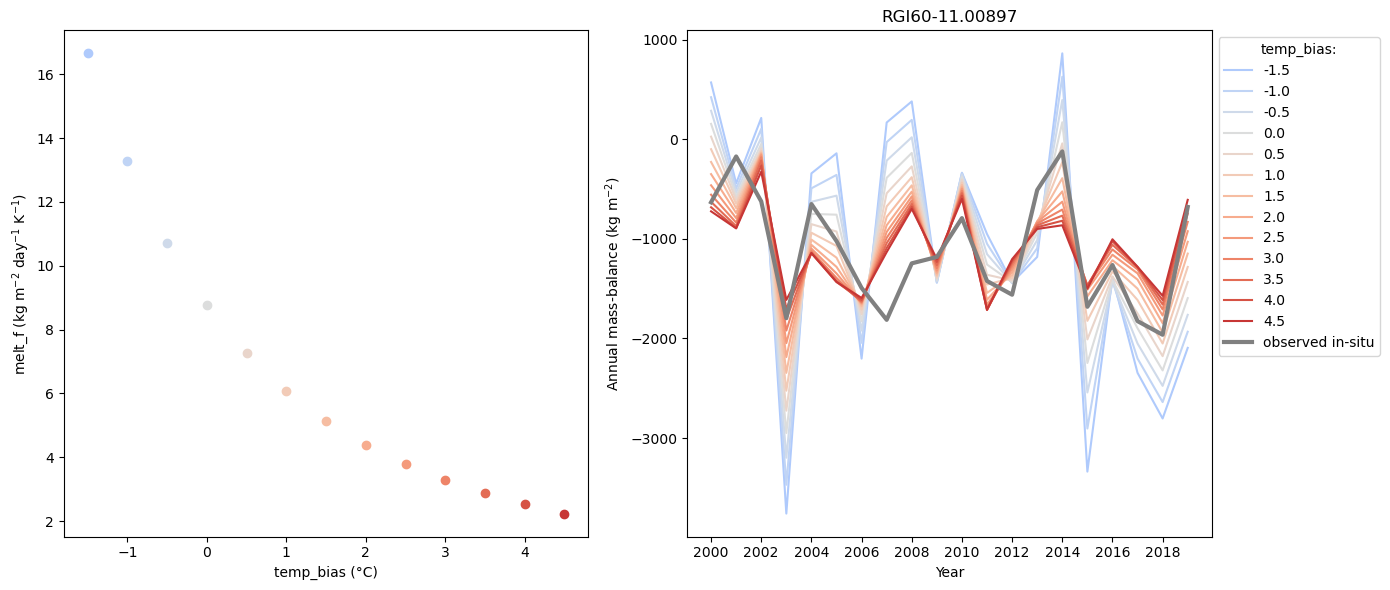

In [52]:
# let's get a nice colormap centered at temp_bias=0
norm = matplotlib.colors.Normalize(vmin=-5, vmax=5.01)
colors_temp_bias = plt.get_cmap('coolwarm')

fig, axs = plt.subplots(1,2,figsize=(14,6))
for j,temp_bias in enumerate(melt_f_dict_tb.keys()):
    axs[0].plot(temp_bias, melt_f_dict_tb[temp_bias], 'o',
             color=colors_temp_bias(norm(temp_bias)))
axs[0].set_ylabel(r'melt_f (kg m$^{-2}$ day$^{-1}$ K$^{-1}$)')
axs[0].set_xlabel('temp_bias (°C)');


for temp_bias in melt_f_dict_tb.keys():
    axs[1].plot(np.arange(2000,2020,1),
             spec_mb_temp_b_sens_dict[temp_bias], '-',
             color=colors_temp_bias(norm(temp_bias)),
             label=temp_bias)
axs[1].plot(mbdf_in_situ.loc[2000:2019].index, mbdf_in_situ.loc[2000:2019]['ANNUAL_BALANCE'], color='grey', lw=3,
        label='observed in-situ')
axs[1].set_ylabel(r'Annual mass-balance (kg m$^{-2}$)')
axs[1].set_xlabel('Year')
axs[1].legend(title='temp_bias:', bbox_to_anchor=(1,1))
axs[1].set_xticks(np.arange(2000,2020,2));
axs[1].set_title(gdir_hef.rgi_id);
plt.tight_layout()

A lower `melt_f` is needed if a positive `temp_bias` is applied... and with that the interannual MB variability gets smaller. 

**Or we change `prcp_fac` and `temp_bias`, and fix the `melt_f`**:

In [53]:
pf_temp_b_dict_tb = {}
spec_mb_pf_temp_b_sens_dict = {}

for temp_bias in np.arange(-5,5.0,0.5):
    # for too negative temp_bias, no prcp_fac is found that matches the observations. We would need to
    # change the melt_f , but here we will just look
    # at those combinations where calibration works with a fixed melt_f.
    try:
        calib_param = mb_calibration_from_scalar_mb(gdir_hef, calibrate_param1='prcp_fac',
                                                    ref_mb=ref_mb, ref_period=cfg.PARAMS['geodetic_mb_period'],
                                                    temp_bias=temp_bias, overwrite_gdir=True)
        pf_temp_b_dict_tb[temp_bias] = calib_param['prcp_fac']
        mb_pf_temp_b_sens = massbalance.MonthlyTIModel(gdir_hef)
        # ok, we actually matched the new ref_mb
        spec_mb_pf_temp_b_sens_dict[temp_bias] = mb_pf_temp_b_sens.get_specific_mb(h, w, year=np.arange(2000,2020,1))
    except RuntimeError:  # 'RGI60-11.00897: ref mb not matched. Try to set calibrate_param2'
        pass

2026-06-05 14:35:19: oggm.core.massbalance: RuntimeError occurred during task mb_calibration_from_scalar_mb on RGI60-11.00897: RGI60-11.00897: ref mb not matched. Try to set calibrate_param2.
2026-06-05 14:35:19: oggm.core.massbalance: RuntimeError occurred during task mb_calibration_from_scalar_mb on RGI60-11.00897: RGI60-11.00897: ref mb not matched. Try to set calibrate_param2.
2026-06-05 14:35:19: oggm.core.massbalance: RuntimeError occurred during task mb_calibration_from_scalar_mb on RGI60-11.00897: RGI60-11.00897: ref mb not matched. Try to set calibrate_param2.
2026-06-05 14:35:19: oggm.core.massbalance: RuntimeError occurred during task mb_calibration_from_scalar_mb on RGI60-11.00897: RGI60-11.00897: ref mb not matched. Try to set calibrate_param2.
2026-06-05 14:35:19: oggm.core.massbalance: RuntimeError occurred during task mb_calibration_from_scalar_mb on RGI60-11.00897: RGI60-11.00897: ref mb not matched. Try to set calibrate_param2.
2026-06-05 14:35:19: oggm.core.massbalan

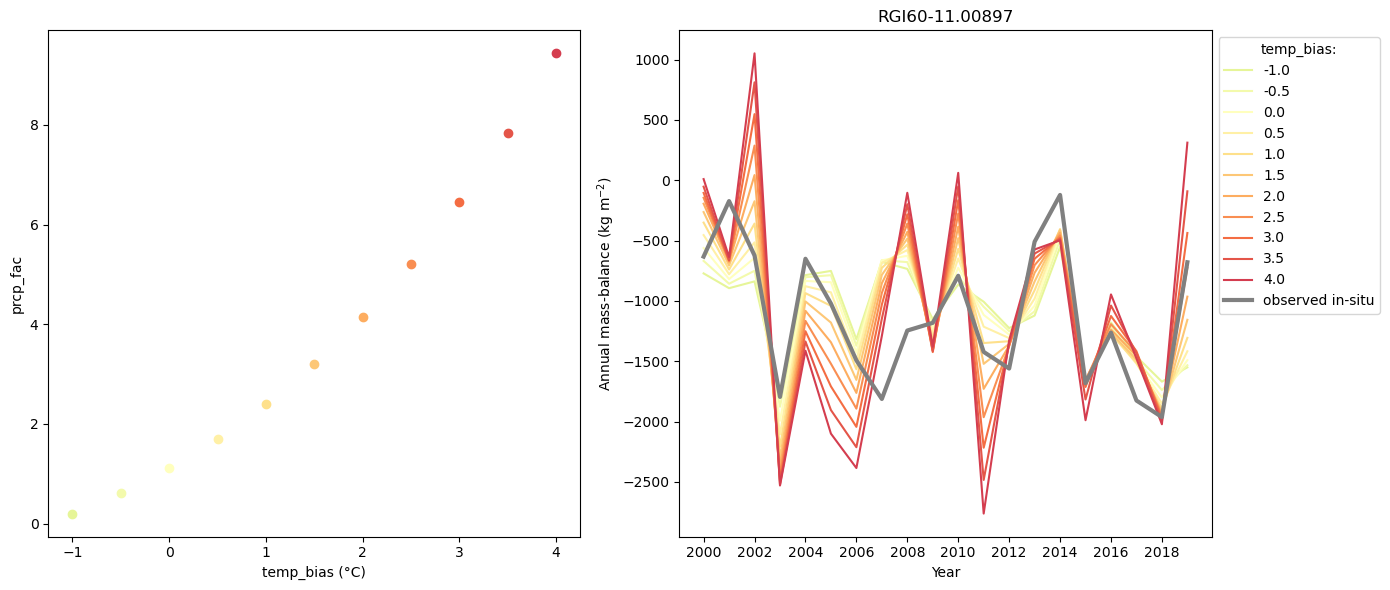

In [54]:
# let's get another centered colormap at temp_bias=0
norm = matplotlib.colors.Normalize(vmin=-5, vmax=5.01)
colors_temp_bias = plt.get_cmap('Spectral_r')

fig, axs = plt.subplots(1,2,figsize=(14,6))
for j,temp_bias in enumerate(pf_temp_b_dict_tb.keys()):
    axs[0].plot(temp_bias, pf_temp_b_dict_tb[temp_bias], 'o',
             color=colors_temp_bias(norm(temp_bias)))
axs[0].set_ylabel(r'prcp_fac')
axs[0].set_xlabel('temp_bias (°C)');


for temp_bias in pf_temp_b_dict_tb.keys():
    axs[1].plot(np.arange(2000,2020,1),
             spec_mb_pf_temp_b_sens_dict[temp_bias], '-',
             color=colors_temp_bias(norm(temp_bias)),
             label=temp_bias)
axs[1].plot(mbdf_in_situ.loc[2000:2019].index, mbdf_in_situ.loc[2000:2019]['ANNUAL_BALANCE'], color='grey', lw=3,
        label='observed in-situ')
axs[1].set_ylabel(r'Annual mass-balance (kg m$^{-2}$)')
axs[1].set_xlabel('Year')
axs[1].legend(title='temp_bias:', bbox_to_anchor=(1,1))
axs[1].set_xticks(np.arange(2000,2020,2));
axs[1].set_title(gdir_hef.rgi_id);
plt.tight_layout()

A larger `temp_bias` needs a larger `prcp_fac` ... and with that the interannual MB variability gets larger.

The parameter combination choice or calibration option also influences the modelled seasonal MB or elevation-dependent MB over the calibration period. Additionally, volume and runoff are influenced by the model parameter choice. If you are further interested in that, you can have a look into [Schuster et al., 2023](https://doi.org/10.1017/aog.2023.57), which analyses the "Glacier projections sensitivity to temperature-index model choices and calibration strategies". 

Using prior knowledge on the MB model parameters by a Bayesian calibration scheme is a good option to constrain the parameter ranges. Like that you can also directly include the MB observation uncertainties and quantify the parameter uncertainties. You can read about that in [Rounce et al., 2020](https://doi.org/10.1017/jog.2019.91)! 

We are working on including a Bayesian calibration framework into OGGM by using the calibration procedure explained below as prior estimates.

## Back to where we started: how did we calibrate the default pre-processed directories in OGGM 1.6?

There are no easy solutions to the problem of overparameterisation. Here we explain the steps taken by OGGM to calibrate the parameters globally for our users who don't want to care about calibration.

In the [preprocessed directories](https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2025.6) MB model calibration is done by using `mb_calibration_from_geodetic_mb` to determine the MB model parameters. We will reproduce the option from the preprocessed directory first:

In [55]:
workflow.execute_entity_task(mb_calibration_from_geodetic_mb,
                             gdir_hef,
                             informed_threestep=True,   # "informed_threestep" is what OGGM used for 1.6
                             overwrite_gdir=True)

2026-06-05 14:35:20: oggm.workflow: Execute entity tasks [mb_calibration_from_geodetic_mb] on 1 glaciers


[{'rgi_id': 'RGI60-11.00897',
  'bias': 0,
  'melt_f': 5.0,
  'prcp_fac': 3.570255710475343,
  'temp_bias': np.float64(1.705035916562294),
  'reference_mb': np.float64(-1100.3),
  'reference_mb_err': np.float64(171.8),
  'reference_period': '2000-01-01_2020-01-01',
  'mb_global_params': {'temp_default_gradient': -0.0065,
   'temp_all_solid': 0.0,
   'temp_all_liq': 2.0,
   'temp_melt': -1.0},
  'baseline_climate_source': 'GSWP3_W5E5',
  'rmsd': 353.7527998459982}]

If you want to know more about that function check its docstring:

In [56]:
# mb_calibration_from_geodetic_mb?

Now how did OGGM come to these parameters?

### First step: data informed precipitation factor 

`prcp_fac` is chosen from a relation to the average winter precipitation. Fig.1 (below) shows the used relationship between winter precipitation and `prcp_fac`.

It was calibrated by adapting `melt_f` and `prcp_fac` to match the average geodetic and winter MB on around 100 glaciers where both datasets are available. [Here](https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/_notebooks/oggm_v16_winter_mb_match_to_prescribe_prcp_fac/figures/RGI60-13.05504_winter_mb_GSWP3_W5E5.png) is an example figure, which shows how the precipitation factor was chosen for such a glacier. The found relationship of decreasing `prcp_fac` for increasing winter precipitation makes sense, as glaciers with already a large winter precipitation should not be corrected with a large multiplicative `prcp_fac`.

<div class="alert alert-info">
    <b>
        The precip factor computed this way should be different for any other dataset you may want to use. Computing it in the same way for your dataset is possible (see code availability section in Schuster et al, 2023), but we don't necessarily recommend to follow the same procedure - our confidence in this methodology is limited (to be fair, any methodology to deal with precipitation is limited).  
    </b>
</div>

In [57]:
w_prcp_array = np.linspace(0.5, 20, 51)
# we basically do here the same as in massbalance.decide_winter_precip_factor(gdir)
a, b = cfg.PARAMS['winter_prcp_fac_ab']
r0, r1 = cfg.PARAMS['prcp_fac_min'], cfg.PARAMS['prcp_fac_max']
prcp_fac = a * np.log(w_prcp_array) + b
# don't allow extremely low/high prcp. factors!!!
prcp_fac_array = utils.clip_array(prcp_fac, r0, r1)
plt.plot(w_prcp_array, prcp_fac_array)
plt.xlabel(r'winter daily mean precipitation' +'\n'+r'(kg m$^{-2}$ day$^{-1}$)')
plt.ylabel('precipitation factor (prcp_fac)'); plt.title('Fig. 1 (only valid for W5E5 and the specific standard OGGM settings)');

KeyError: 'winter_prcp_fac_ab'

This relationship is only valid for W5E5 with the specific standard OGGM settings. We repeated the same approach with ERA5, and found that the precipitation factor decreases rather linearly with the winter precipitation for this dataset ([figure that shows the fits for both climate datasets and includes the underlying winter-MB-calibrated precipitation factors](https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/_notebooks/oggm_v16_winter_mb_match_to_prescribe_prcp_fac/comparison_oggm_v16_GSWP3_W5E5_vs_ERA5_calib_log_fit_pf_distribution_change_monthly_cte_melt_f_minus_1.png)). The higher resolution of ERA5 compared to W5E5 may explain the different estimated relationships. Further details are provided in the [jupyter notebook used to estimate the fits](https://nbviewer.org/urls/cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/_notebooks/oggm_v16_winter_mb_match_to_prescribe_prcp_fac/match_winter_mb_w5e5_era5.ipynb).

### Second step: data informed temperature bias

Using this data-informed precipitation factor, we then do a global calibration where the temperature bias (`temp_bias`) is calibrated, while the melt factor (`melt_f`) is fixed at 5 kg m-2 day-1 K-1 (default value based on [Schuster et al., 2023](https://doi.org/10.1017/aog.2023.57)). 

The idea is that if many glaciers within the same grid point need a temperature bias to reach the observed MB, this indicates that a systematic correction is necessary (at least for this MB model in particular). In fact, we can plot the median bias required to match MB observations using this technique, which gives us the following plot (here for OGGM v1.6.1, but it is very similar in v1.6.3):

![err](https://user-images.githubusercontent.com/10050469/224318400-ec1d8825-d7e7-4cdb-94f3-ebb95b8f7120.jpg)

The fact that the `temp_bias` parameter is spatially correlated (many regions are all blue or red) indicate that something in the data needs to be corrected for our model. It is this information that we use to inform the next step.

**The code we used for this step is available [here](https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/calibration/1.6.3/). As explained above, we do a global run with a fixed precipitation factor and melt factor, then store the resulting parameters in a csv file used by OGGM. This is repeated for each climate dataset and RGI version. The csv file using W5E5 and RGI 6.2 can be found [here](https://cluster.klima.uni-bremen.de/~oggm/ref_mb_params/oggm_v1.6/w5e5_rgi6_perglacier_temp_bias_v2025.6.2.csv).**

<div class="alert alert-info">
    <b>
        Similar to the precipitation factor, we do not necessarily recommend our users to use this method in their own calibration effort. We don't think it's a bad method, but given the importance of calibration we think that diversity is important!
    </b>
</div>

### Third step: local calibration using the data informed precipitation factor and temperature bias as first guesses

Finally, we now run [mb_calibration_from_scalar_mb](https://docs.oggm.org/en/latest/generated/oggm.tasks.mb_calibration_from_scalar_mb.html) again for each glacier, as follows:
- use the first guess: `melt_f` = 5, `prcp_fac` = data-informed from step 1, `temp_bias` = data-informed from step 2
- if this doesn't match (this would be highly unlikely), allow `prcp_fac` to vary again between 0.8 and 1.2 times the original guess ($\pm$20%). This is justified by the fact that the first guess for precipitation is also highly uncertain. If that worked, the calibration stops (33.6% of all glaciers worldwide are calibrated this way, for 41.3% of the total area).
- if the above did not work, allow `melt_f` to vary again. If that worked, the calibration stops (60.4% of all glaciers worldwide are calibrated this way, for 56.4% of the total area).
- finally, if the above did not work, allow `temp_bias` to vary again (6.0% of all glaciers worldwide are calibrated this way, for 2.2% of the total area).

*(numbers computed by the [massbalance_global_params.ipynb notebook](massbalance_global_params.ipynb) and are valid for the OGGM v1.6.3 (2025.6) W5E5 gdir)*

<div class="alert alert-info">
    <b>
        This informed step-wise calibration is the option that is used operationally in OGGM>=v1.6 in the preprocessed directories (L>=3) for all glaciers world-wide! Note also that if you use the glacier directories with dynamical spinup enabled (our recommendation), then the melt factors are recalibrated once again.
    </b>
</div>

### A look into the global parameter distributions 

See [massbalance_global_params.ipynb](massbalance_global_params.ipynb)

## Take home points

- We illustrated how a mass-balance (MB) model of a glacier can be calibrated in OGGM.  
- We can use different observational data for calibration: 
    - calibrating to geodetic observations using different time periods, to in-situ direct glaciological observations from the WGMS (if available) or to other custom MB data.  
- There exist different ways of calibrating to the average observational data:
    - You can use the same option (`informed_threestep`) as done operationally for the [preprocessed directories (L>=3)](https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2025.6) on all glaciers world-wide
    - you can calibrate the `melt_f`, and have the `prcp_fac` and `temp_bias` fixed. If the calibration does not work, the `temp_bias` can be varied as well.
    - you can also calibrate instead on `prcp_fac` or `temp_bias` and fix the other parameters.
- However, we showed that the parameter combination choice has an influence on other estimates than the average MB (which then influences also future projections). 
- As user of OGGM, you might just use the calibrated MB model parameters from the preprocessed directories. Nevertheless, it is good to be aware of the overparameterisation problem. In addition, if you want to include uncertainties of the MB model calibration, you could include additional experiments that use another calibration option and create your own preprocessed directories with these options. With more available observational data or improved climate data, you might also be able to use better ways to calibrate the MB model parameters. 


## What's next?

- Check out the [massbalance_global_params.ipynb](massbalance_global_params.ipynb) notebook
- return to the [OGGM documentation](https://docs.oggm.org)
- back to the [table of contents](../welcome.ipynb)